In [3]:
import numpy as np
import matplotlib.pyplot as plt

### Normal:

In [29]:
mu = 0
sigma = 4
N = 10000
X =  np.random.normal(mu,sigma,N)
print(X.size)
X

10000


array([-7.14749373,  2.49319767,  7.69930311, ..., -3.83036152,
        1.5271062 , -8.18472914])

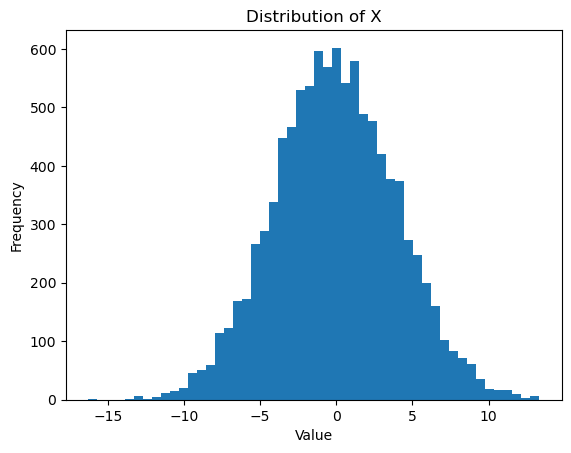

In [14]:
plt.figure()
plt.hist(X, bins=50)
plt.title("Distribution of X")
plt.ylabel("Frequency")
plt.xlabel("Value")
plt.show()

In [88]:
cumavg = np.zeros(len(X))

for i in range(len(X)):
    cumavg[i] = np.mean(X[:i+1])
cumavg

array([-7.14749373, -2.32714803,  1.01500235, ..., -0.04616275,
       -0.04600541, -0.04681928])

In [89]:
stderr = np.zeros(len(X))

for i in range(len(X)):
    s = np.std(X[:i+1])
    stderr[i] = s / np.sqrt(i+1)
    
stderr

array([0.        , 3.40849913, 3.55107621, ..., 0.03993163, 0.03992794,
       0.03993224])

In [90]:
mean = (np.mean(X))
median = (np.median(X))
print(mean,median)

-0.04681928095617118 -0.08137556246888743


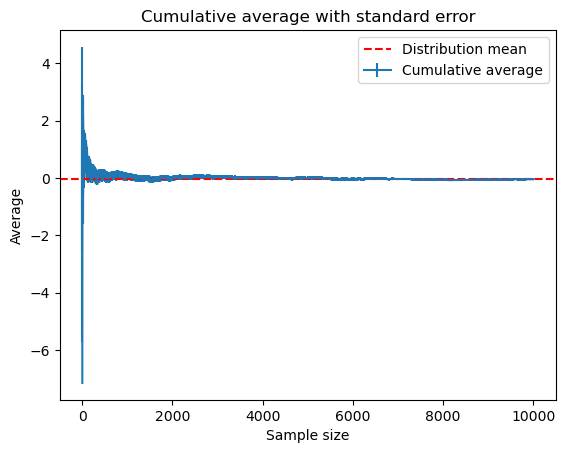

In [91]:
plt.figure()

x = np.arange(1, len(cumavg)+1)

plt.errorbar(x, cumavg, yerr=stderr, fmt='-', label="Cumulative average")
plt.axhline(mean, color='r', linestyle='--', label="Distribution mean")

plt.xlabel("Sample size")
plt.ylabel("Average")
plt.title("Cumulative average with standard error")
plt.legend()

plt.show()

In [53]:
cummedian = np.zeros(len(X))

for i in range(len(X)):
    cummedian[i] = np.median(X[:i+1])
    
cummedian

array([-7.14749373, -2.32714803,  2.49319767, ..., -0.08137556,
       -0.07994471, -0.08137556])

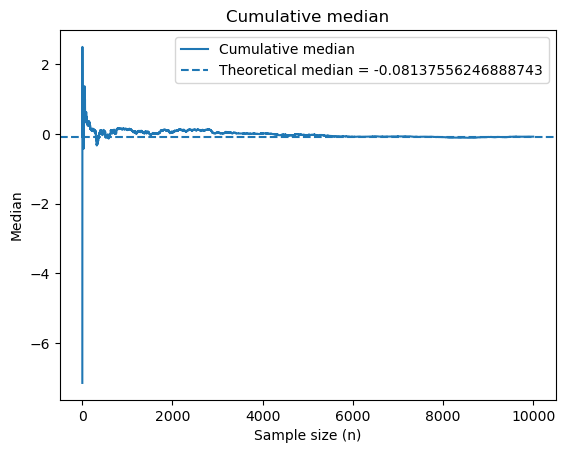

In [ ]:

plt.figure()
x = np.arange(1, len(X) + 1)

plt.plot(x, cummedian, label="Cumulative median")
plt.axhline(median, linestyle="--", label=f"Theoretical median = {median}")

plt.xlabel("Sample size (n)")
plt.ylabel("Median")
plt.title("Cumulative median")
plt.legend()
plt.show()

#### Pareto:

In [92]:
N = 10000
xm = 1
alfa = 0.5

Y = (np.random.pareto(alfa,N) + xm )
Y

array([6.97822648e+01, 2.14373866e+00, 1.25355511e+01, ...,
       1.01037318e+05, 1.31082034e+00, 1.34936419e+01])

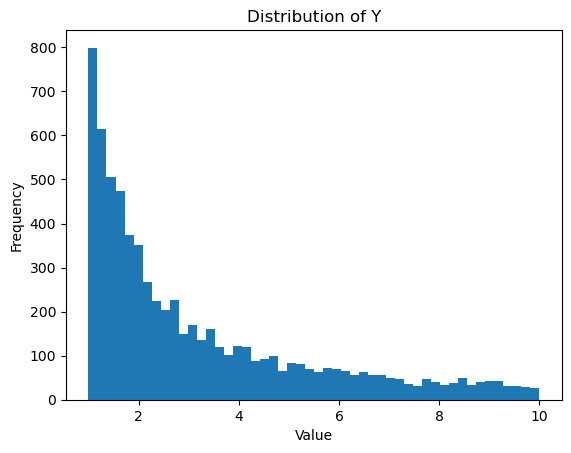

In [93]:
plt.figure()
plt.hist(Y, bins=50,  range= (xm, 10))
plt.title("Distribution of Y")
plt.ylabel("Frequency")
plt.xlabel("Value")
plt.show()

In [94]:
cumavgy = np.zeros(len(Y))

for i in range(len(Y)):
    cumavgy[i] = np.mean(Y[:i+1])
cumavgy

array([6.97822648e+01, 3.59630018e+01, 2.81538515e+01, ...,
       6.45459080e+04, 6.45394529e+04, 6.45330003e+04])

In [95]:
stderry = np.zeros(len(Y))

for i in range(len(Y)):
    s = np.std(Y[:i+1])
    stderry[i] = s / np.sqrt(i+1)
    
stderry

array([0.00000000e+00, 2.39138303e+01, 1.71703299e+01, ...,
       3.23097154e+04, 3.23064848e+04, 3.23032548e+04])

In [96]:
meany = (np.mean(Y))
mediany = (np.median(Y))
print(mean,median)

-0.04681928095617118 -0.08137556246888743


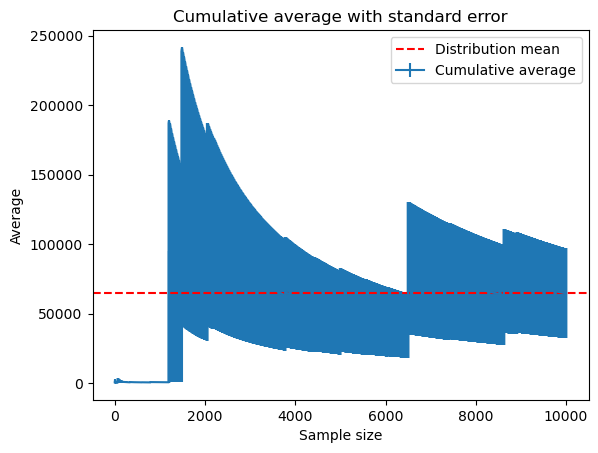

In [97]:
plt.figure()

y = np.arange(1, len(cumavgy)+1)

plt.errorbar(y, cumavgy, yerr=stderry, fmt='-', label="Cumulative average")
plt.axhline(meany, color='r', linestyle='--', label="Distribution mean")

plt.xlabel("Sample size")
plt.ylabel("Average")
plt.title("Cumulative average with standard error")
plt.legend()

plt.show()

In [98]:
cummediany = np.zeros(len(X))

for i in range(len(X)):
    cummediany[i] = np.median(X[:i+1])
    
cummediany

array([-7.14749373, -2.32714803,  2.49319767, ..., -0.08137556,
       -0.07994471, -0.08137556])

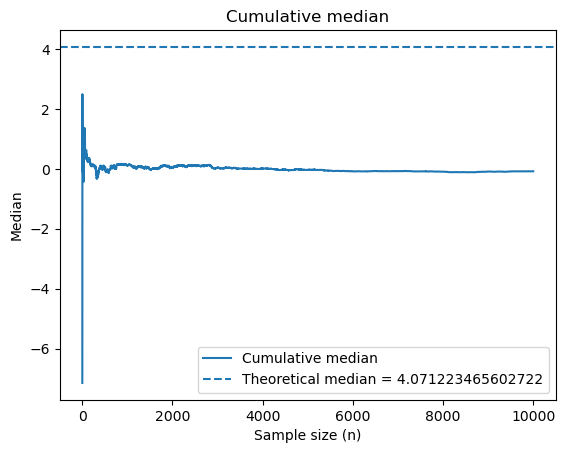

In [ ]:
plt.figure()
y = np.arange(1, len(X) + 1)

plt.plot(y, cummediany, label="Cumulative median")
plt.axhline(mediany, linestyle="--", label=f"Theoretical median = {mediany}")

plt.xlabel("Sample size (n)")
plt.ylabel("Median")
plt.title("Cumulative median")
plt.legend()
plt.show()

### Paper dataset

In [16]:
import pandas as pd

df = pd.read_csv("../more_than_one_author_papers_dataset.csv")

citations = df["cited_by_count"].to_numpy()
print(citations)
mean_citations = np.mean(citations)
median_citations = np.median(citations)

print("Mean citations:", mean_citations)
print("Median citations:", median_citations)

sample = df.sample(n=10000, random_state=1)

sample_citations = sample["cited_by_count"]


[10484  2939  2510 ...    12    46    13]
Mean citations: 117.78539665111172
Median citations: 41.0


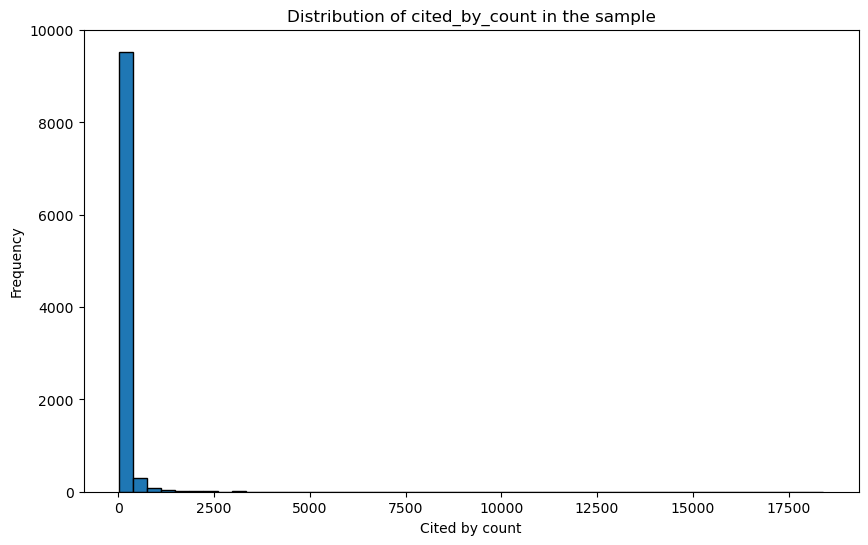

In [19]:

plt.figure(figsize=(10, 6))
plt.hist(sample_citations, bins=50, edgecolor="black")
plt.title("Distribution of cited_by_count in the sample")
# plt.xscale("log")
plt.xlabel("Cited by count")
plt.ylabel("Frequency")
plt.show()

In [20]:
n = np.arange(1, len(sample_citations) + 1)
cumulative_average = np.cumsum(sample_citations) / n

print(cumulative_average)

27894     14.000000
18683     30.500000
17363     39.000000
23289     80.500000
29936     67.800000
            ...    
23198    109.572329
32763    109.565570
28350    109.563413
35363    109.558256
21636    109.549400
Name: cited_by_count, Length: 10000, dtype: float64


In [24]:
paper_cumavg = np.zeros(len(sample_citations))

for i in range(len(sample_citations)):
    paper_cumavg[i] = np.mean(sample_citations[:i+1])

paper_cumavg

array([ 14.        ,  30.5       ,  39.        , ..., 109.56341268,
       109.55825583, 109.5494    ])

In [25]:
paper_stderr = np.zeros(len(sample_citations))

for i in range(len(sample_citations)):
    s = np.std(sample_citations[:i+1], ddof=1)
    paper_stderr[i] = s / np.sqrt(i+1)
    
paper_stderr

array([        nan, 16.5       , 12.76714533, ...,  3.65420974,
        3.65384791,  3.65349324])

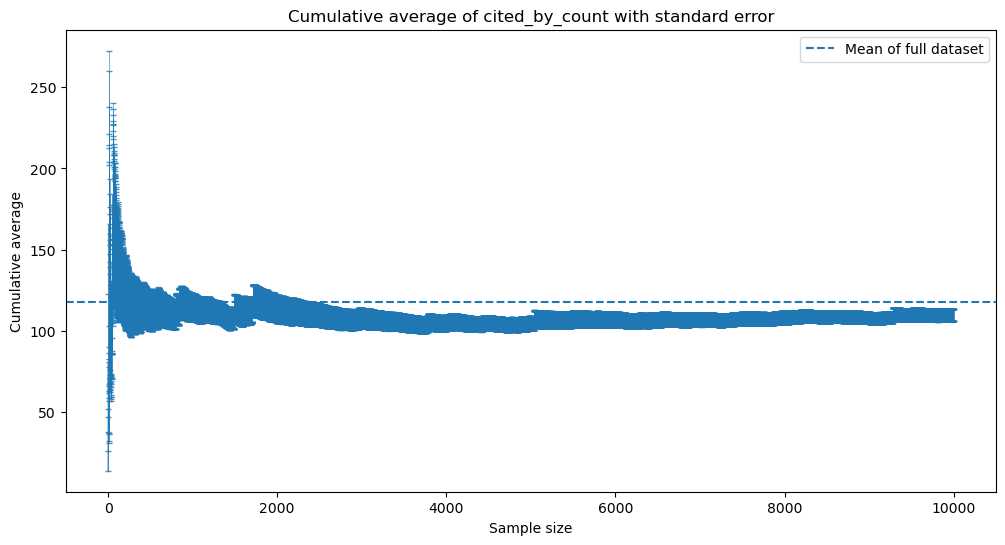

In [26]:
plt.figure(figsize=(12, 6))

plt.errorbar(
    n,
    cumulative_average,
    yerr=paper_stderr,
    fmt='-',
    linewidth=1,
    elinewidth=0.5,
    capsize=2,
    alpha=0.8
)

plt.axhline(mean_citations, linestyle='--', label='Mean of full dataset')

plt.title("Cumulative average of cited_by_count with standard error")
plt.xlabel("Sample size")
plt.ylabel("Cumulative average")
plt.legend()
plt.show()

In [27]:
cumulative_median = np.array([
    np.median(sample_citations[:i])
    for i in range(1, len(sample_citations) + 1)
])

print(cumulative_median)

[14.  30.5 47.  ... 41.  41.  41. ]


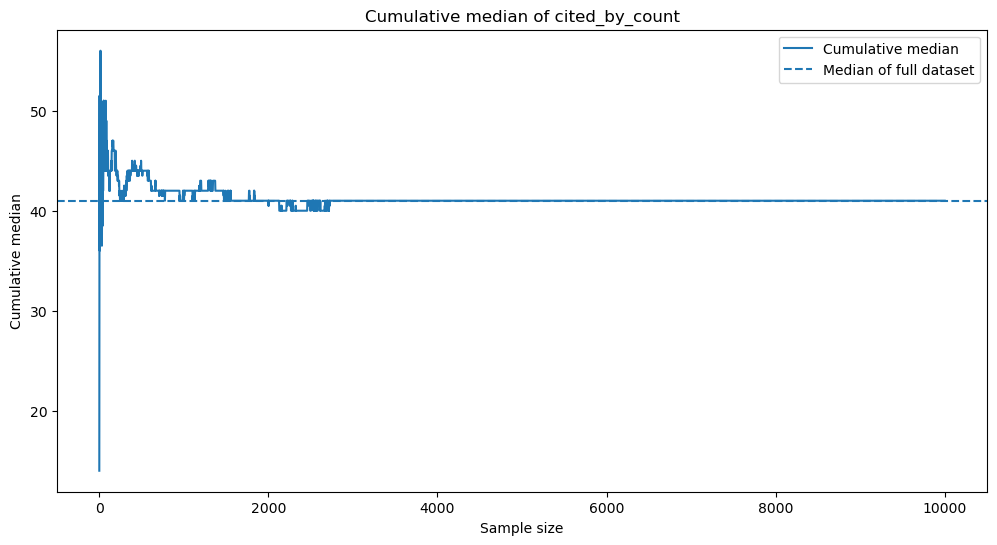

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(n, cumulative_median, linewidth=1.5, label="Cumulative median")
plt.axhline(median_citations, linestyle='--', label='Median of full dataset')

plt.title("Cumulative median of cited_by_count")
plt.xlabel("Sample size")
plt.ylabel("Cumulative median")
plt.legend()
plt.show()